In [1]:
!pip install pytorch-tabnet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE

from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import os
import joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# ======================================
# LOAD DATASET
# ======================================
DATA_PATH = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
df = pd.read_csv(DATA_PATH)

print("Shape data:", df.shape)
df.head()

Shape data: (613, 31)


,Hypothyroidism,Creatinine,Diabetes Mellitus (DM),Alanin Aminotransferaz (ALT),Low Density Lipoprotein (LDL),Hemoglobin (HGB),Coronary Artery Disease (CAD),Total Body Fat Ratio (TBFR) (%),Total Body Water (TBW),Height,...,Aspartat Aminotransferaz (AST),Glomerular Filtration Rate (GFR),Glucose,TC/HDL Ratio,LDL/HDL Ratio,Atherogenic Index,Triglyceride/HDL Ratio,Non-Lean Mass (NLM),Body Fat/Water Ratio,De Ritis Ratio
0,0,1.36,1,83.0,6.5,37.8,0,25.213043,36.87740,160.0,...,13.6,54.218927,130.0,6.243386,0.343915,5.243386,15.555556,-5.786957,0.683699,0.163855
1,0,0.81,0,16.0,75.0,14.3,0,13.352632,34.10012,170.0,...,25.0,94.586269,100.0,2.000000,1.000000,1.000000,0.866667,-29.647368,0.391571,1.562500
2,0,0.81,0,15.0,78.0,14.5,0,20.100000,34.67564,160.0,...,20.0,99.353543,100.0,2.083333,1.083333,1.083333,0.944444,-19.900000,0.579658,1.333333
3,0,0.81,0,14.0,78.0,15.1,0,21.885714,39.11164,170.0,...,23.0,99.353543,100.0,2.000000,1.040000,1.000000,0.866667,-8.114286,0.559570,1.642857
4,0,0.72,0,14.0,80.0,12.3,0,29.500000,26.26800,150.0,...,25.0,93.612393,98.0,2.384615,1.230769,1.384615,1.076923,-20.500000,1.123039,1.785714


In [4]:
# ======================================
# SPLIT FEATURES & TARGET
# ======================================
target_col = "Gallstone Status"

X = df.drop(columns=[target_col])
y = df[target_col]

In [5]:
# Encode target jika string
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# ======================================
# ENCODING CATEGORICAL
# ======================================
X_encoded = pd.get_dummies(X)

# ======================================
# SCALING NUMERICAL
# ======================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Final shape:", X_scaled.shape)

Final shape: (613, 30)


In [6]:
# ======================================
# HOLD OUT 80:20
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

In [7]:
# ======================================
# SMOTE UNTUK DATA IMBALANCE
# ======================================
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Sebelum SMOTE :", np.bincount(y_train))
print("Sesudah SMOTE :", np.bincount(y_train_sm))


Sebelum SMOTE : [361 129]
Sesudah SMOTE : [361 361]


In [8]:
# ======================================
# TRAIN TABNET
# ======================================
tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    verbose=1
)

tabnet_clf.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    eval_metric=["auc"],
    max_epochs=200,
    patience=20,
    batch_size=256,
    virtual_batch_size=128
)


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.35642 | val_0_auc: 0.53777 |  0:00:00s
epoch 1  | loss: 1.20547 | val_0_auc: 0.5704  |  0:00:01s
epoch 2  | loss: 1.27617 | val_0_auc: 0.54052 |  0:00:01s
epoch 3  | loss: 1.11094 | val_0_auc: 0.52095 |  0:00:02s
epoch 4  | loss: 1.12983 | val_0_auc: 0.52026 |  0:00:02s
epoch 5  | loss: 1.0779  | val_0_auc: 0.55769 |  0:00:03s
epoch 6  | loss: 1.1117  | val_0_auc: 0.57967 |  0:00:04s
epoch 7  | loss: 1.01861 | val_0_auc: 0.56044 |  0:00:04s
epoch 8  | loss: 1.06623 | val_0_auc: 0.57005 |  0:00:05s
epoch 9  | loss: 1.00826 | val_0_auc: 0.55975 |  0:00:05s
epoch 10 | loss: 1.02557 | val_0_auc: 0.60955 |  0:00:06s
epoch 11 | loss: 0.99218 | val_0_auc: 0.62363 |  0:00:06s
epoch 12 | loss: 0.95432 | val_0_auc: 0.5831  |  0:00:07s
epoch 13 | loss: 0.97451 | val_0_auc: 0.59581 |  0:00:07s
epoch 14 | loss: 0.8265  | val_0_auc: 0.60989 |  0:00:07s
epoch 15 | loss: 0.83582 | val_0_auc: 0.62672 |  0:00:07s
epoch 16 | loss: 0.77749 | val_0_auc: 0.63324 |  0:00:08s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [9]:
# ======================================
# PREDIKSI
# ======================================
y_pred = tabnet_clf.predict(X_test)
y_pred_proba = tabnet_clf.predict_proba(X_test)[:, 1]


In [10]:
# ======================================
# METRIK EVALUASI
# ======================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("===== EVALUASI TABNET =====")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)
print("ROC AUC  :", auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

===== EVALUASI TABNET =====
Accuracy : 0.7235772357723578
Precision: 0.4807692307692308
Recall   : 0.78125
F1 Score : 0.5952380952380952
ROC AUC  : 0.8131868131868132

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.70      0.79        91
           1       0.48      0.78      0.60        32

    accuracy                           0.72       123
   macro avg       0.69      0.74      0.69       123
weighted avg       0.79      0.72      0.74       123



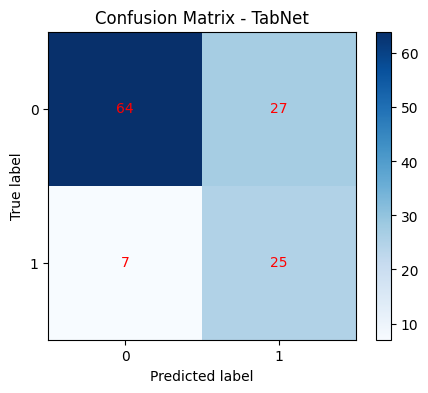

In [11]:
# ======================================
# CONFUSION MATRIX
# ======================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - TabNet")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color="red")

plt.show()

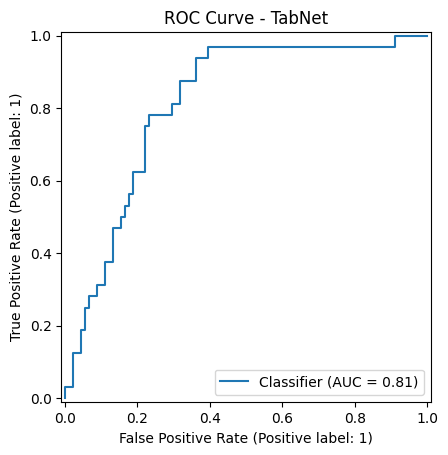

In [12]:
# ======================================
# ROC CURVE
# ======================================
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("ROC Curve - TabNet")
plt.show()


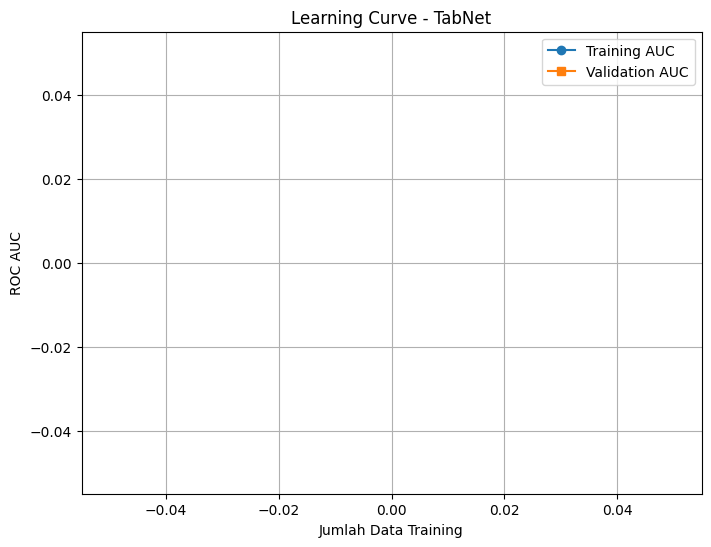

In [13]:
# ======================================
# LEARNING CURVE (Baru Ditambahkan)
# ======================================

# Buat model baru khusus learning curve
tabnet_lc = TabNetClassifier(
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    verbose=0
)

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=tabnet_lc,
    X=X_train_sm,
    y=y_train_sm,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

# Hitung mean & std
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Training AUC", marker='o')
plt.plot(train_sizes, valid_mean, label="Validation AUC", marker='s')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.2)

plt.title("Learning Curve - TabNet")
plt.xlabel("Jumlah Data Training")
plt.ylabel("ROC AUC")
plt.grid()
plt.legend()
plt.show()


In [14]:
# ======================================
# SAVE MODEL & SCALER
# ======================================
output_dir = "/content/drive/MyDrive/Tesis/Fix FE HO/TabNet/Base Model"
os.makedirs(output_dir, exist_ok=True)

tabnet_clf.save_model(output_dir + "tabnet_model")

joblib.dump(scaler, output_dir + "scaler.pkl")
joblib.dump(X_encoded.columns.tolist(), output_dir + "columns.pkl")

print("Model & scaler berhasil disimpan.")

Successfully saved model at /content/drive/MyDrive/Tesis/Fix FE HO/TabNet/Base Modeltabnet_model.zip
Model & scaler berhasil disimpan.


In [15]:
# ======================================
# INSTALL & IMPORT
# ======================================
!pip install pytorch-tabnet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.over_sampling import SMOTE

from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import os
import joblib

In [16]:
# ======================================
# LOAD DATASET
# ======================================
DATA_PATH = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
df = pd.read_csv(DATA_PATH)

print("Shape data:", df.shape)
df.head()

Shape data: (613, 31)


,Hypothyroidism,Creatinine,Diabetes Mellitus (DM),Alanin Aminotransferaz (ALT),Low Density Lipoprotein (LDL),Hemoglobin (HGB),Coronary Artery Disease (CAD),Total Body Fat Ratio (TBFR) (%),Total Body Water (TBW),Height,...,Aspartat Aminotransferaz (AST),Glomerular Filtration Rate (GFR),Glucose,TC/HDL Ratio,LDL/HDL Ratio,Atherogenic Index,Triglyceride/HDL Ratio,Non-Lean Mass (NLM),Body Fat/Water Ratio,De Ritis Ratio
0,0,1.36,1,83.0,6.5,37.8,0,25.213043,36.87740,160.0,...,13.6,54.218927,130.0,6.243386,0.343915,5.243386,15.555556,-5.786957,0.683699,0.163855
1,0,0.81,0,16.0,75.0,14.3,0,13.352632,34.10012,170.0,...,25.0,94.586269,100.0,2.000000,1.000000,1.000000,0.866667,-29.647368,0.391571,1.562500
2,0,0.81,0,15.0,78.0,14.5,0,20.100000,34.67564,160.0,...,20.0,99.353543,100.0,2.083333,1.083333,1.083333,0.944444,-19.900000,0.579658,1.333333
3,0,0.81,0,14.0,78.0,15.1,0,21.885714,39.11164,170.0,...,23.0,99.353543,100.0,2.000000,1.040000,1.000000,0.866667,-8.114286,0.559570,1.642857
4,0,0.72,0,14.0,80.0,12.3,0,29.500000,26.26800,150.0,...,25.0,93.612393,98.0,2.384615,1.230769,1.384615,1.076923,-20.500000,1.123039,1.785714


In [17]:
# ======================================
# SPLIT FEATURES & TARGET
# ======================================
target_col = "Gallstone Status"

X = df.drop(columns=[target_col])
y = df[target_col]

if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# ======================================
# ENCODING CATEGORICAL
# ======================================
X_encoded = pd.get_dummies(X)

# ======================================
# SCALING
# ======================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [18]:
# ======================================
# HOLD OUT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

# ======================================
# SMOTE
# ======================================
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_sm))

Before SMOTE: [361 129]
After SMOTE: [361 361]


In [19]:
# =======================================================
# TABNET WRAPPER AGAR BISA DIGUNAKAN DI RANDOM SEARCH
# =======================================================
class TabNetWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, n_d=32, n_a=32, n_steps=5, gamma=1.5, lr=1e-3):
        self.n_d = n_d
        self.n_a = n_a
        self.n_steps = n_steps
        self.gamma = gamma
        self.lr = lr
        self.model = None

    def fit(self, X, y):
        self.model = TabNetClassifier(
            n_d=self.n_d,
            n_a=self.n_a,
            n_steps=self.n_steps,
            gamma=self.gamma,
            optimizer_fn=torch.optim.Adam,
            optimizer_params={"lr": self.lr},
            lambda_sparse=1e-4,
            verbose=0
        )
        self.model.fit(
            X, y,
            eval_set=[(X, y)],
            max_epochs=100,
            patience=15,
            batch_size=256,
            virtual_batch_size=128
        )
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_proba(self, X):
        return self.model.predict_proba(X)


In [20]:
# ======================================
# RANDOM SEARCH PARAMETER SPACE
# ======================================
param_dist = {
    "n_d": [16, 32, 64],
    "n_a": [16, 32, 64],
    "n_steps": [3, 4, 5, 6],
    "gamma": [1.0, 1.2, 1.5, 2.0],
    "lr": [1e-2, 5e-3, 1e-3, 5e-4]
}

tabnet_rs = TabNetWrapper()

random_search = RandomizedSearchCV(
    estimator=tabnet_rs,
    param_distributions=param_dist,
    n_iter=10,
    cv=10,
    scoring="roc_auc",
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("\n🔍 Starting Random Search...")
random_search.fit(X_train_sm, y_train_sm)

print("\n===== BEST RESULT (Random Search) =====")
print("Best AUC :", random_search.best_score_)
print("Best Params :", random_search.best_params_)



🔍 Starting Random Search...
Fitting 10 folds for each of 10 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Stop training because you reached max_epochs = 100 with best_epoch = 99 and best_val_0_auc = 0.93612

===== BEST RESULT (Random Search) =====
Best AUC : nan
Best Params : {'n_steps': 5, 'n_d': 32, 'n_a': 32, 'lr': 0.001, 'gamma': 1.2}


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [21]:
# Simpan best params
output_dir = "/content/drive/MyDrive/Tesis/Fix FE HO/TabNet/Tuned Model/"
os.makedirs(output_dir, exist_ok=True)


In [22]:
import json
with open(output_dir + "best_params.json", "w") as f:
    json.dump(random_search.best_params_, f, indent=4)

# ======================================================
# TRAIN FINAL MODEL DENGAN BEST PARAMS
# ======================================================
best_params = random_search.best_params_

tabnet_best = TabNetWrapper(**best_params)
tabnet_best.fit(X_train_sm, y_train_sm)


Stop training because you reached max_epochs = 100 with best_epoch = 99 and best_val_0_auc = 0.93612


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNetWrapper(gamma=1.2)

In [23]:
# ======================================
# PREDIKSI
# ======================================
y_pred = tabnet_best.predict(X_test)
y_pred_proba = tabnet_best.predict_proba(X_test)[:, 1]


In [24]:
# ======================================
# METRIK EVALUASI
# ======================================
print("===== FINAL EVALUATION (BEST MODEL) =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


===== FINAL EVALUATION (BEST MODEL) =====
Accuracy : 0.6504065040650406
Precision: 0.39215686274509803
Recall   : 0.625
F1 Score : 0.4819277108433735
ROC AUC  : 0.7506868131868132

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.66      0.74        91
           1       0.39      0.62      0.48        32

    accuracy                           0.65       123
   macro avg       0.61      0.64      0.61       123
weighted avg       0.72      0.65      0.67       123



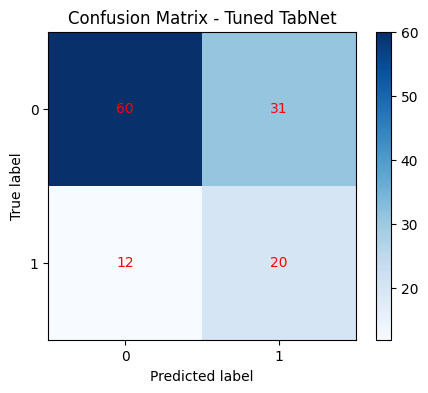

In [29]:
# ======================================
# CONFUSION MATRIX
# ======================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Tuned TabNet")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='red')

plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

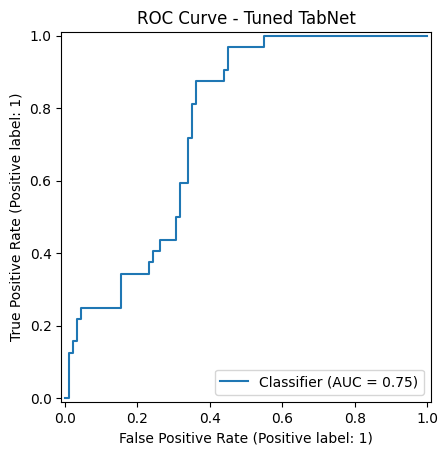

In [30]:
# ======================================
# ROC CURVE
# ======================================
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("ROC Curve - Tuned TabNet")
plt.show()


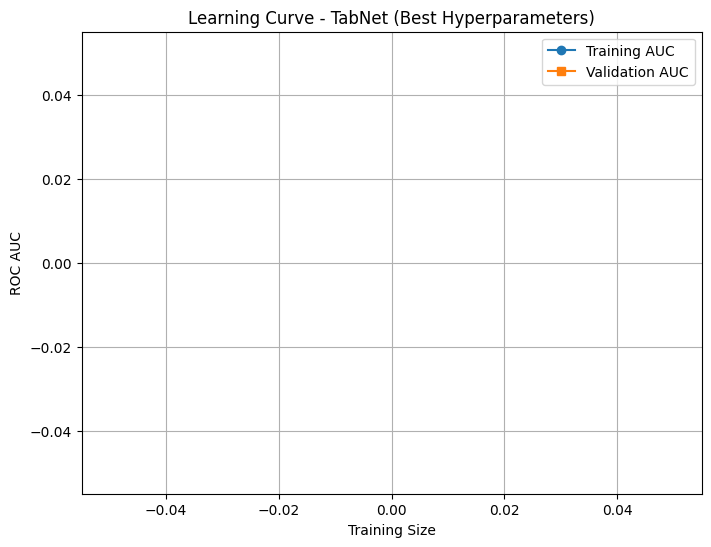

In [27]:
# ======================================
# LEARNING CURVE
# ======================================
tabnet_lc = TabNetWrapper(**best_params)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=tabnet_lc,
    X=X_train_sm,
    y=y_train_sm,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Training AUC', marker="o")
plt.plot(train_sizes, test_mean, label='Validation AUC', marker="s")

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, test_mean-test_std, test_mean+test_std, alpha=0.2)

plt.title("Learning Curve - TabNet (Best Hyperparameters)")
plt.xlabel("Training Size")
plt.ylabel("ROC AUC")
plt.legend()
plt.grid()
plt.show()


In [28]:
# ======================================
# SAVE FINAL MODEL
# ======================================
joblib.dump(scaler, output_dir + "scaler.pkl")
joblib.dump(X_encoded.columns.tolist(), output_dir + "columns.pkl")

print("\nModel, scaler, dan best params berhasil disimpan.")


Model, scaler, dan best params berhasil disimpan.
